In [1]:
import numpy as np
from sklearn.metrics import precision_score, classification_report

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # use same size you trained with
BATCH_SIZE = 32         # use same batch size

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\Data\REFUGE2\val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False   # IMPORTANT for metrics
)


Found 770 images belonging to 2 classes.


In [7]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\notebooks\Phase_4_EfficientNet\best_model.h5")


In [8]:
import numpy as np
from sklearn.metrics import classification_report

y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Glaucoma"]
)

print(report)

25/25 [==============================] - 376s 13s/step


c:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

              precision    recall  f1-score   support

      Normal       0.50      1.00      0.67       385
    Glaucoma       0.00      0.00      0.00       385

    accuracy                           0.50       770
   macro avg       0.25      0.50      0.33       770
weighted avg       0.25      0.50      0.33       770



In [9]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\notebooks\Phase_4_EfficientNet\best_model.h5")


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\Admin\OneDrive\Desktop\Glaucoma_GAN_project\Data\REFUGE2\val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 770 images belonging to 2 classes.


In [12]:
import numpy as np

y_true = val_generator.classes


In [13]:
y_pred_probs = model.predict(val_generator)


25/25 [==============================] - 372s 13s/step


In [15]:
y_scores = y_pred_probs[:, 0]

In [16]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_true, y_scores)

print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.509768932366335


In [18]:
import os

os.makedirs("results", exist_ok=True)

plt.savefig("results/roc_curve.png")


<Figure size 640x480 with 0 Axes>

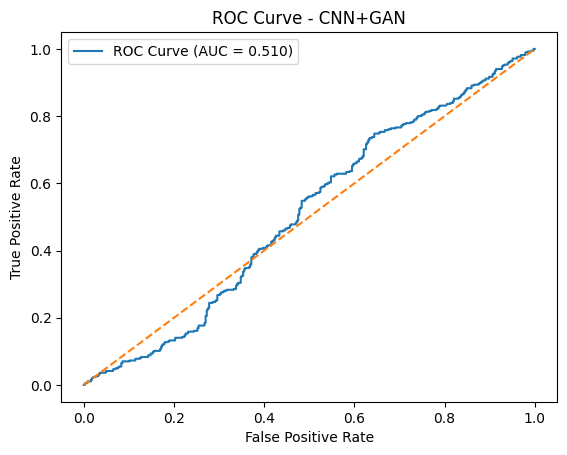

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN+GAN")
plt.legend()
plt.savefig("results/roc_curve.png")
plt.show()


In [20]:
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(val_generator)

# Convert probabilities to 0 or 1 (threshold = 0.5)
y_pred = (y_pred_probs.ravel() > 0.5).astype(int)

# True labels
y_true = val_generator.classes


25/25 [==============================] - 263s 10s/step


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[  0 385]
 [  0 385]]


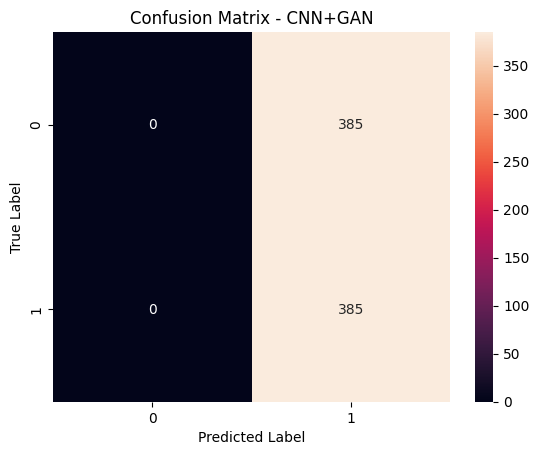

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN+GAN")
plt.show()


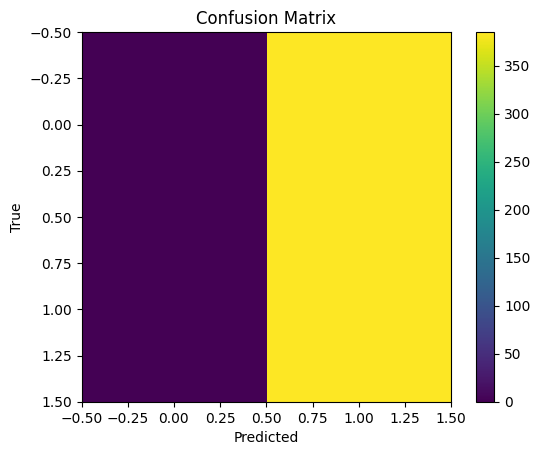

In [23]:
plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [24]:
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)


Accuracy: 0.5
Precision: 0.5
Recall (Sensitivity): 1.0
Specificity: 0.0


In [25]:
print(y_pred_probs.shape)


(770, 1)


In [26]:
print(np.unique(y_pred, return_counts=True))


(array([1]), array([770], dtype=int64))


In [27]:
print(np.unique(y_true, return_counts=True))


(array([0, 1]), array([385, 385], dtype=int64))


In [29]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)


NameError: name 'train_generator' is not defined

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D


In [32]:
Dense(1, activation='sigmoid')


In [33]:
loss='binary_crossentropy'


In [34]:
print(np.unique(y_pred, return_counts=True))


(array([1]), array([770], dtype=int64))


In [35]:
print(history.history.keys())


NameError: name 'history' is not defined